In [1]:
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path
import torch, os

# Adjust to point to the actual root of your project
PROJECT_ROOT = Path.cwd().parent  # or Path("/absolute/path/to/your/project")
sys.path.insert(0, str(PROJECT_ROOT))

from src.activation_recorder import MultiPromptActivations
from src.time_series_activations import MultiPromptTimeSeries


/home/p84400019/miniconda3/envs/int/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
save_dir = "../data/activations"
file_path = os.path.join(save_dir, "multi_prompt_activations.pkl")
activations = MultiPromptActivations.load(file_path)

MultiPromptActivations successfully loaded from '../data/activations/multi_prompt_activations.pkl'.


Prompt 0 has 10 generated tokens: ['.', '\n', 'I', ' don', '’', 't', ' know', ' any', ' jokes', '.']


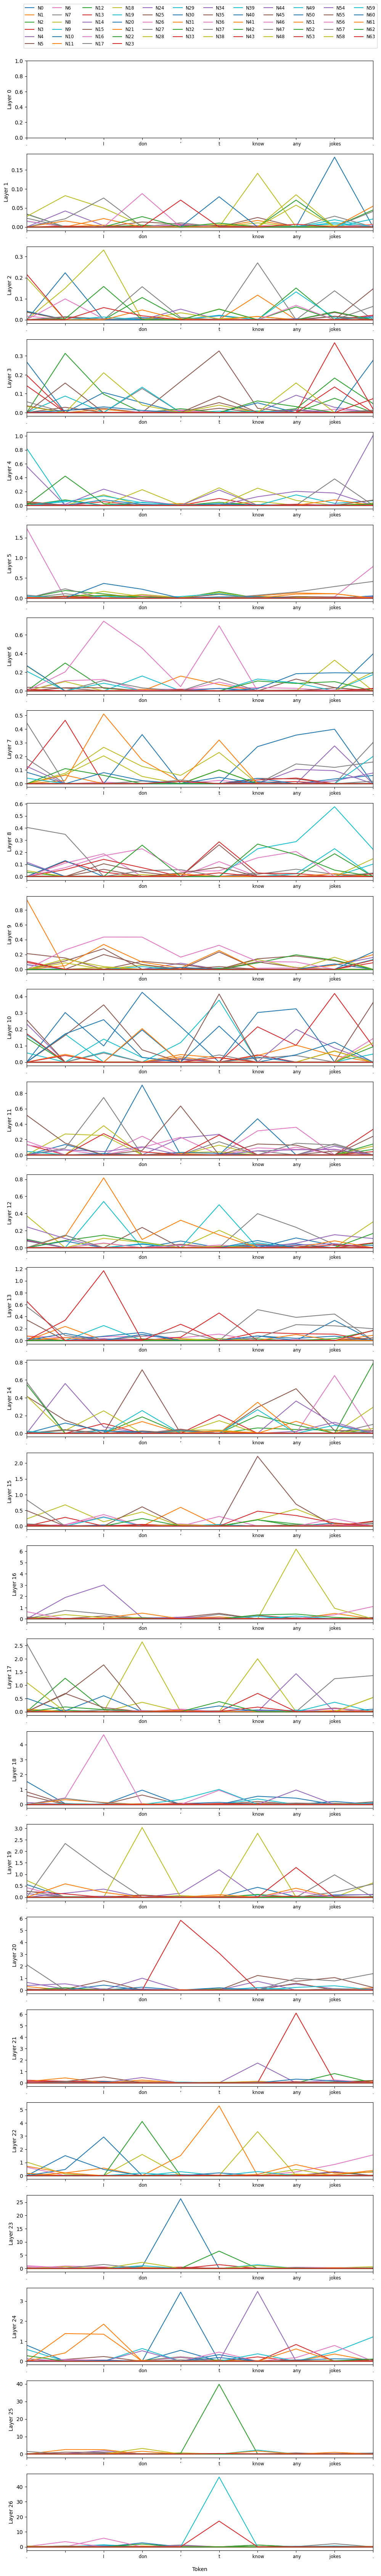

Prompt 1 has 10 generated tokens: [' a', ' program', ' that', ' prints', ' ', '“', 'Hello', ',', ' world', '!']


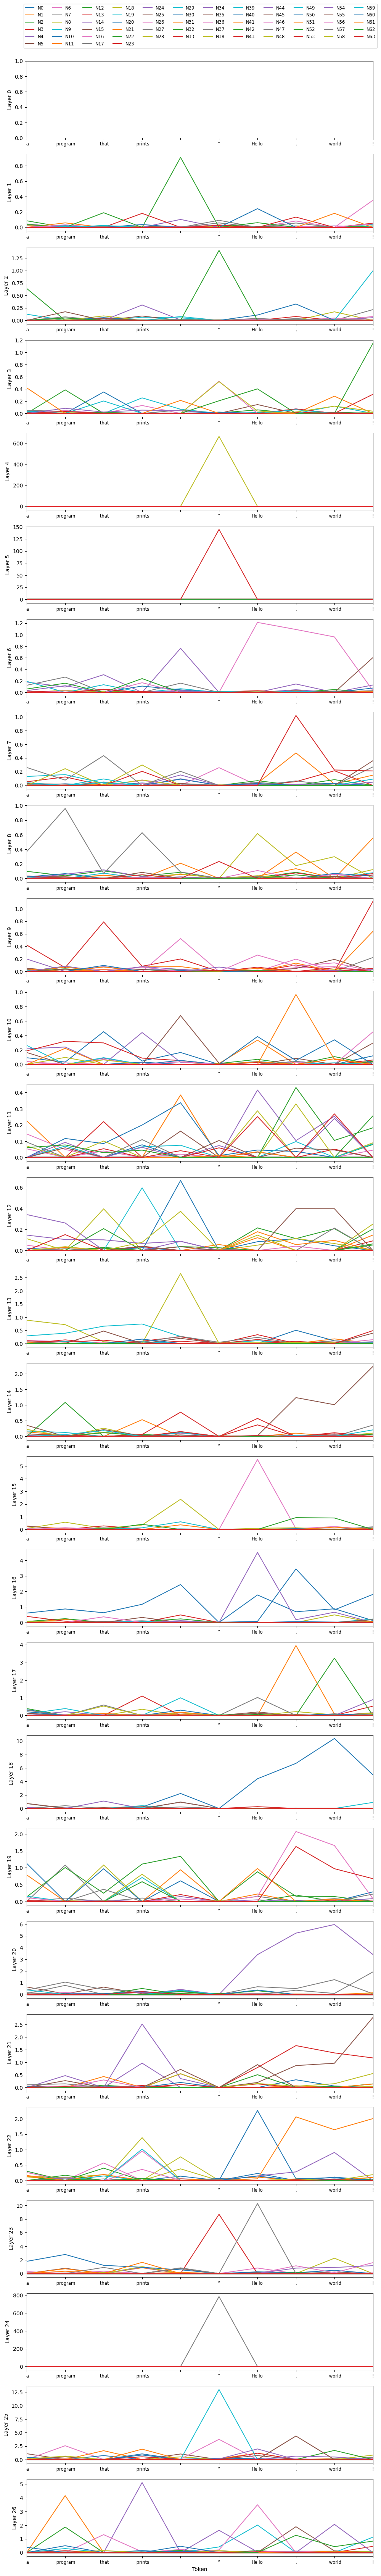

In [26]:
time_series = MultiPromptTimeSeries.from_activations(
    activations, 
    node_type="moe",  node_activation="expert_output",
    # node_type="attention", node_activation="attention_outputs",
    projection_method="norm", 
    exclude_shared_expert_moe=True, 
)
time_series.plot(token_x=True, ticks_all_layers=True)